<a href="https://colab.research.google.com/github/onlyforstudy7770-cpu/DeepFake-voice-detection-project/blob/main/CNN_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

CNN (Convolutional Neural Network)
first i make ann then  cnn

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers , models
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


I alredy uploaded the traning and testing data in the google drive so i dont have to wait for dataset to download

In [ ]:
!unzip -q "/content/drive/MyDrive/ASVsfoop_data/train_s_db.zip" -d "/content/train_log_mfcc"

In [ ]:
!unzip -q "/content/drive/MyDrive/ASVsfoop_data/eval_s_db.zip" -d "/content/eval_log_mfcc"


In [ ]:
import numpy as np
import pandas as pd
import os
import glob
from tqdm import tqdm

mfcc_folder_path = "/content/train_log_mfcc/train_s_db"
csv_file_path = "/content/drive/MyDrive/ASVsfoop_data/train.csv"

#loding the csv data in pandas DataFrame
print("Loading CSV...")
df = pd.read_csv(csv_file_path)


df['filename'] = df['filename'].astype(str)

# making a dictonary for fast lookups
target_map = dict(zip(df["filename"], df["target"]))

# Dont know what is this doing but dont touch that
file_paths = glob.glob(os.path.join(mfcc_folder_path, "*.npy"))
file_paths.sort()


X_train_list = []
y_train_list = []

print(f"Found {len(file_paths)} files. Starting data loading...")

for file_path in tqdm(file_paths):

    full_filename = os.path.basename(file_path)

    # Removing ".flac.npy" to get just the ID (e.g., "LA_T_123")
    csv_key = full_filename.replace(".flac.npy", "").replace(".npy", "")

    # Only load if the file exists in our CSV map

    if csv_key in target_map:
        # Load the MFCC data
        data = np.load(file_path)

        X_train_list.append(data)
        y_train_list.append(int(target_map[csv_key]))

X_train = np.array(X_train_list)
y_train = np.array(y_train_list)

print("\nLoading Complete.")
print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")

Loading CSV...
Found 25380 files. Starting data loading...


100%|██████████| 25380/25380 [00:23<00:00, 1068.65it/s]



Loading Complete.
X_train shape: (25380, 128, 126)
y_train shape: (25380,)


In [ ]:
import numpy as np
import pandas as pd
import os
import glob
from tqdm import tqdm

mfcc_folder_path = "/content/eval_log_mfcc/eval_s_db"
csv_file_path = "/content/drive/MyDrive/ASVsfoop_data/eval.csv"


print("Loading CSV...")
df = pd.read_csv(csv_file_path)

df['filename'] = df['filename'].astype(str)
target_map = dict(zip(df["filename"], df["target"]))

file_paths = glob.glob(os.path.join(mfcc_folder_path, "*.npy"))
file_paths = file_paths[:10000]
file_paths.sort()

X_train_list = []
y_train_list = []

print(f"Found {len(file_paths)} files. Starting data loading...")


for file_path in tqdm(file_paths):
    full_filename = os.path.basename(file_path)

    csv_key = full_filename.replace(".flac.npy", "").replace(".npy", "")

    if csv_key in target_map:
        data = np.load(file_path)
        X_train_list.append(data)
        y_train_list.append(int(target_map[csv_key]))
    else:
        pass
X_test = np.array(X_train_list)
y_test = np.array(y_train_list)

print("\nLoading Complete.")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

Loading CSV...
Found 10000 files. Starting data loading...


100%|██████████| 10000/10000 [00:01<00:00, 7990.14it/s]



Loading Complete.
X_train shape: (10000, 128, 126)
y_train shape: (10000,)


Testing the  Artificial Neural Network model

In [ ]:

ann = models.Sequential([
    # Input(shape = (128, 126)),
    layers.Flatten(input_shape=( 128 , 126) ),
    layers.Dense(10000, activation='relu'),
    layers.Dense(2500, activation='relu'),
    layers.Dense(100, activation='relu'),
   layers.Dense(1, activation='sigmoid')
])
ann.compile(
    optimizer='SGD',
    loss='binary_crossentropy',
    metrics=['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
ann.fit(X_train/100, y_train, epochs=8, batch_size=32)

Epoch 1/8
794/794 ━━━━━━━━━━━━━━━━━━━━ 18s 22ms/step - accuracy: 0.9010 - loss: 0.3127
Epoch 2/8
794/794 ━━━━━━━━━━━━━━━━━━━━ 19s 21ms/step - accuracy: 0.8983 - loss: 0.2435
Epoch 3/8
794/794 ━━━━━━━━━━━━━━━━━━━━ 17s 21ms/step - accuracy: 0.9070 - loss: 0.2152
Epoch 4/8
794/794 ━━━━━━━━━━━━━━━━━━━━ 17s 21ms/step - accuracy: 0.9137 - loss: 0.1989
Epoch 5/8
794/794 ━━━━━━━━━━━━━━━━━━━━ 17s 22ms/step - accuracy: 0.9165 - loss: 0.1868
Epoch 6/8
794/794 ━━━━━━━━━━━━━━━━━━━━ 17s 21ms/step - accuracy: 0.9273 - loss: 0.1731
Epoch 7/8
794/794 ━━━━━━━━━━━━━━━━━━━━ 17s 21ms/step - accuracy: 0.9330 - loss: 0.1637
Epoch 8/8
794/794 ━━━━━━━━━━━━━━━━━━━━ 17s 21ms/step - accuracy: 0.9333 - loss: 0.1606


In [ ]:
ann.evaluate( X_test , y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.8601 - loss: 15.8872


[15.897321701049805, 0.8604000210762024]

In [ ]:
from sklearn.metrics import confusion_matrix , classification_report

In [ ]:
y_pred = ann.predict(X_test)


313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step


In [ ]:
print( classification_report(y_test , y_pred.round()))

              precision    recall  f1-score   support

           0       0.40      0.73      0.52      1021
           1       0.97      0.88      0.92      8979

    accuracy                           0.86     10000
   macro avg       0.68      0.80      0.72     10000
weighted avg       0.91      0.86      0.88     10000



In [ ]:
X_train = np.array(X_train)
y_train = np.array(y_train)

X_test = np.array(X_test)
y_test = np.array(y_test)

In [ ]:
X_train = X_train.reshape(-1, 128, 126, 1)
X_test = X_test.reshape(-1, 128, 126, 1)

In [ ]:
X_train.shape

(25380, 128, 126, 1)

normalizing the data poiints into 0 to 1 , otherwise the model is not being able to learn

In [ ]:

import numpy as np

# 1. Calculate the global min and max from your training set
# (We use the training set stats to scale the test set later to avoid data leakage)
min_val = np.min(X_train)
max_val = np.max(X_train)

print(f"Original Range: {min_val} to {max_val}")

# 2. Apply Min-Max Normalization
# Formula: (X - min) / (max - min)
X_train_norm = (X_train - min_val) / (max_val - min_val)
X_test_norm = (X_test - min_val) / (max_val - min_val)

print(f"New Range: {np.min(X_train_norm)} to {np.max(X_train_norm)}")

Original Range: -80.0 to 0.0
New Range: 0.0 to 1.0


In [ ]:
from sklearn.utils import class_weight
import numpy as np

# Calculate weights based on y_train (your training labels)
weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

# Convert to a dictionary (Format required by Keras/TensorFlow)
class_weights_dict = dict(enumerate(weights))

print(f"Computed Class Weights: {class_weights_dict}")

Computed Class Weights: {0: np.float64(4.9186046511627906), 1: np.float64(0.5565789473684211)}


In [ ]:
# Model 1 , first model which was made


cnn = models.Sequential([


    Input(shape=(128 , 126 , 1)),
    layers.Conv2D(filters = 128, kernel_size = (3, 3), activation='relu'),
    layers.MaxPooling2D ((2,2)),
    layers.Conv2D(filters = 64, kernel_size = (3, 3), activation='relu'),
    layers.MaxPooling2D ((2,2)),
    layers.Flatten(),
    layers.Dense(90, activation='relu'),
    layers.Dense(10, activation='relu'),
   layers.Dense(1, activation='sigmoid')
])
cnn.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy'])

In [ ]:
cnn.fit(X_train_norm, y_train, epochs=8, batch_size=32)

Epoch 1/8
794/794 ━━━━━━━━━━━━━━━━━━━━ 36s 39ms/step - accuracy: 0.8889 - loss: 1.2970
Epoch 2/8
794/794 ━━━━━━━━━━━━━━━━━━━━ 28s 35ms/step - accuracy: 0.9030 - loss: 0.2370
Epoch 3/8
794/794 ━━━━━━━━━━━━━━━━━━━━ 28s 35ms/step - accuracy: 0.9244 - loss: 0.1804
Epoch 4/8
794/794 ━━━━━━━━━━━━━━━━━━━━ 28s 35ms/step - accuracy: 0.9468 - loss: 0.1381
Epoch 5/8
794/794 ━━━━━━━━━━━━━━━━━━━━ 28s 35ms/step - accuracy: 0.9670 - loss: 0.0886
Epoch 6/8
794/794 ━━━━━━━━━━━━━━━━━━━━ 28s 35ms/step - accuracy: 0.9722 - loss: 0.0736
Epoch 7/8
794/794 ━━━━━━━━━━━━━━━━━━━━ 28s 35ms/step - accuracy: 0.9768 - loss: 0.0678
Epoch 8/8
794/794 ━━━━━━━━━━━━━━━━━━━━ 30s 37ms/step - accuracy: 0.9835 - loss: 0.0455


In [ ]:

from tensorflow.keras import layers, models, Input

# model 2 , which is use for evaluating the audio samples
cnn = models.Sequential([
    Input(shape=(128, 126, 1)),

    layers.Conv2D(32, (3, 3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D((2, 2)),


    layers.Flatten(),


    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(64, activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(1, activation='sigmoid')
])

# for lower learning rate
opt = tf.keras.optimizers.Adam(learning_rate=0.0001)

cnn.compile(
    optimizer=opt,
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history = cnn.fit(
    X_train_norm,
    y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_test, y_test),
    class_weight=class_weights_dict
)

Epoch 1/10
794/794 ━━━━━━━━━━━━━━━━━━━━ 38s 35ms/step - accuracy: 0.7164 - loss: 0.7603 - val_accuracy: 0.8979 - val_loss: 255.6982
Epoch 2/10
794/794 ━━━━━━━━━━━━━━━━━━━━ 20s 26ms/step - accuracy: 0.8629 - loss: 0.2395 - val_accuracy: 0.8979 - val_loss: 419.6025
Epoch 3/10
794/794 ━━━━━━━━━━━━━━━━━━━━ 21s 26ms/step - accuracy: 0.9194 - loss: 0.1420 - val_accuracy: 0.8979 - val_loss: 374.8417
Epoch 4/10
794/794 ━━━━━━━━━━━━━━━━━━━━ 20s 25ms/step - accuracy: 0.9700 - loss: 0.0687 - val_accuracy: 0.8979 - val_loss: 789.2748
Epoch 5/10
794/794 ━━━━━━━━━━━━━━━━━━━━ 20s 26ms/step - accuracy: 0.9857 - loss: 0.0438 - val_accuracy: 0.8979 - val_loss: 620.3821
Epoch 6/10
794/794 ━━━━━━━━━━━━━━━━━━━━ 20s 25ms/step - accuracy: 0.9903 - loss: 0.0342 - val_accuracy: 0.8979 - val_loss: 1085.0153
Epoch 7/10
794/794 ━━━━━━━━━━━━━━━━━━━━ 21s 26ms/step - accuracy: 0.9881 - loss: 0.0330 - val_accuracy: 0.8979 - val_loss: 1709.9856
Epoch 8/10
794/794 ━━━━━━━━━━━━━━━━━━━━ 20s 25ms/step - accuracy: 0.9862 -

In [ ]:
cnn.evaluate( X_test_norm , y_test) # for evaluation

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.6737 - loss: 2.3745


[2.4180586338043213, 0.6693000197410583]

In [ ]:
from sklearn.metrics import confusion_matrix , classification_report
y_pred = cnn.predict(X_test_norm)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step


It catches all the spoof audio (recall value is 1) ,
but the Precision is only about 22%.          
I consider this model superior to the Random Forest model because it successfully detects all fake audio samples, which is our primary objective. Since we can verify the false positives manually, this high-recall approach is ideal for high-security systems where missing a threat is not an option.

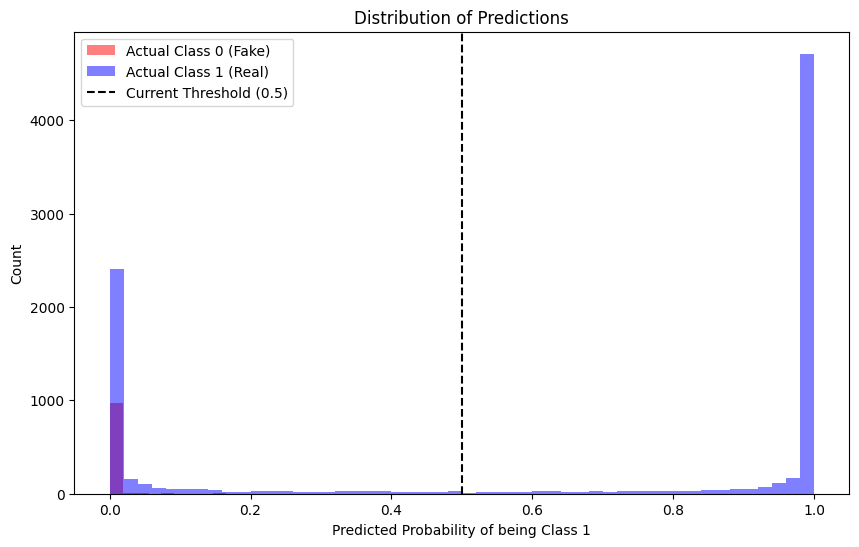

In [ ]:
import matplotlib.pyplot as plt

pred_class_0 = y_pred[y_test == 0]
pred_class_1 = y_pred[y_test == 1]

plt.figure(figsize=(10,6))
plt.hist(pred_class_0, bins=50, alpha=0.5, label='Actual Class 0 (Fake)', color='red')
plt.hist(pred_class_1, bins=50, alpha=0.5, label='Actual Class 1 (Real)', color='blue')
plt.axvline(x=0.5, color='black', linestyle='--', label='Current Threshold (0.5)')
plt.legend()
plt.title('Distribution of Predictions')
plt.xlabel('Predicted Probability of being Class 1')
plt.ylabel('Count')
plt.show()

In [ ]:
print( classification_report(y_test , y_pred.round()))

              precision    recall  f1-score   support

           0       0.23      0.99      0.38      1021
           1       1.00      0.63      0.77      8979

    accuracy                           0.67     10000
   macro avg       0.62      0.81      0.58     10000
weighted avg       0.92      0.67      0.73     10000



In [ ]:
print(classification_report(y_test, (y_pred > 0.7).astype(int)))

              precision    recall  f1-score   support

           0       0.22      1.00      0.37      1021
           1       1.00      0.61      0.76      8979

    accuracy                           0.65     10000
   macro avg       0.61      0.80      0.56     10000
weighted avg       0.92      0.65      0.72     10000

